## Image Classification with Deep Learning 

### Introduction
For our practical session, we are going to inplement on of the most common computer vision tasks- image classification. We will use the CIFAR-10 dataset. The CIFAR-10 dataset is a widely used collection of 60,000 small, 32x32 color images divided into 10 distinct object classes (like airplanes, cats, cars, dogs, ships, trucks) for training and testing computer vision models, with 50,000 images for training and 10,000 for testing, serving as a benchmark for algorithm performance in machine learning. 

For this task we will need to also install a new librarry called keras.So go ahead and run 
```pip install --upgrade keras``` on your terminal.


In [5]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### 1. Load & Explore the Data

In [6]:
from tensorflow.keras import datasets # type: ignore

(X_train, y_train), (X_test,y_test) = datasets.cifar10.load_data()
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(50000, 32, 32, 3) (10000, 32, 32, 3) (50000, 1) (10000, 1)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train,y_train, test_size=0.2, random_state=42,stratify=y_train)
print(X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape)

(40000, 32, 32, 3) (10000, 32, 32, 3) (10000, 32, 32, 3) (40000, 1) (10000, 1) (10000, 1)


Let us confirm that the data looks correct and inspect a couple of images...

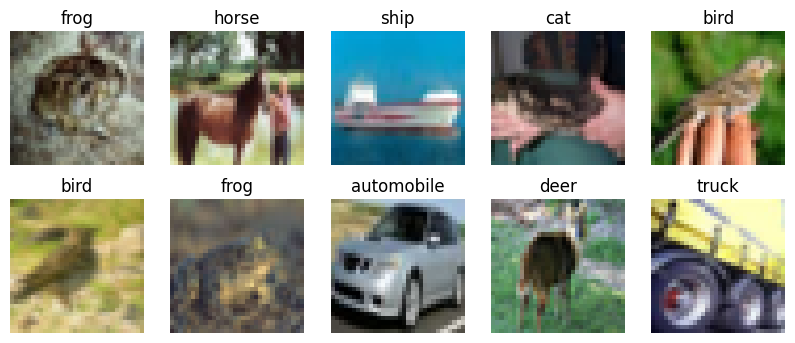

In [8]:
# CIFAR-10 class names
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Display some sample images
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])  
    plt.axis('off')
plt.show()

### 2. Image Pre-processing

**2.1 Normalization**

Remember, our images are represented as a grid of pixel values. Pixel values can range from between 0-255. If the input pixel values are large and widely varied, it means the network will have very large gradients and may not converge. So we normalize to limit shrink the pixel values between 0 and 1

In [9]:
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

Other pre-processing steps typical in computer vision is image augmentation. Here, you can flip images, rotate them, adjust their contrast, edge detection and so much more. But for this dataset, we have enough training samples, and we want to see the model performance first, then we can come back to make the decision on whether augmentation is actually necessary.

Explore the open CV library for methods used in image augmentation...

### 3. Model Building & Training

In [10]:
from tensorflow.keras import layers, models # type: ignore
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense, Flatten # type: ignore


fcnn = Sequential()

#flattened input layer
fcnn.add(Flatten(input_shape=(32,32,3)))

#hidden layers
fcnn.add(Dense(1024, activation='relu'))
fcnn.add(Dense(512, activation='relu'))
fcnn.add(Dense(256, activation='relu'))

#output layer
fcnn.add(Dense(10, activation='softmax'))
print("Added Dense Output Layer (10 neurons, Softmax activation)")

# Display the model architecture summary
fcnn.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
fcnn.summary()

d:\Advanced_Machine_Learning\adml-env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Added Dense Output Layer (10 neurons, Softmax activation)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Train the model
history = fcnn.fit(
    X_train, y_train,
    batch_size=52,
    epochs=5,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/5
770/770 ━━━━━━━━━━━━━━━━━━━━ 43s 51ms/step - accuracy: 0.3115 - loss: 1.9046 - val_accuracy: 0.3488 - val_loss: 1.7903
Epoch 2/5
770/770 ━━━━━━━━━━━━━━━━━━━━ 37s 48ms/step - accuracy: 0.3841 - loss: 1.7098 - val_accuracy: 0.3804 - val_loss: 1.7071
Epoch 3/5
770/770 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - accuracy: 0.4148 - loss: 1.6205 - val_accuracy: 0.4128 - val_loss: 1.6519
Epoch 4/5
770/770 ━━━━━━━━━━━━━━━━━━━━ 39s 51ms/step - accuracy: 0.4399 - loss: 1.5612 - val_accuracy: 0.4307 - val_loss: 1.6079
Epoch 5/5
770/770 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.4575 - loss: 1.5084 - val_accuracy: 0.4339 - val_loss: 1.6068


Determining the appropriate number of epoch
Plot the training accuracy against the no. of epochs

In [12]:
#Model performance of the FCNN
loss, accuracy = fcnn.evaluate(X_val, y_val, verbose=0)

print(f"\nFinal Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy:.4f}")


Final Validation Loss: 1.6068
Final Validation Accuracy: 0.4339


In [13]:
# Build a simple CNN model
cnn_model = models.Sequential([
    #cnn part
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),

    #fcnn part
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 classes
])

cnn_model.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
cnn_model.summary()

d:\Advanced_Machine_Learning\adml-env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

**Conv2D layer (Convolutional layer)**

- 32 filters → the layer will learn 32 different feature maps (like edges, textures).
(3,3) 
- kernel size → small 3x3 sliding window for detecting features.
- Activation='relu' → introduces non-linearity and helps the network learn complex patterns.
- input_shape=(32,32,3) → input images are 32x32 pixels with 3 color channels (RGB).

**Max Pooling layer**

Reduces the spatial size of feature maps by taking the maximum value in each 2x2 window.Helps reduce computation. After this, feature maps become smaller (half the height and width).

**Dense (fully connected) layer**

- 64 neurons, ReLU activation.Learns complex combinations of features extracted by convolutional layers.

**Output layer**

- 10 neurons → one for each CIFAR-10 class.
- Softmax activation → converts outputs into probabilities that sum to 1.The class with the highest probability is the model’s prediction.

In [14]:
history = cnn_model.fit(
    X_train, y_train,
    batch_size=52,
    epochs=5,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/5
770/770 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.4120 - loss: 1.5949 - val_accuracy: 0.5045 - val_loss: 1.3718
Epoch 2/5
770/770 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.5617 - loss: 1.2336 - val_accuracy: 0.6032 - val_loss: 1.1315
Epoch 3/5
770/770 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.6224 - loss: 1.0761 - val_accuracy: 0.6456 - val_loss: 1.0268
Epoch 4/5
770/770 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.6639 - loss: 0.9629 - val_accuracy: 0.6456 - val_loss: 1.0300
Epoch 5/5
770/770 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.6923 - loss: 0.8812 - val_accuracy: 0.6841 - val_loss: 0.9256


In [15]:
#Model performance of the CNN
loss, accuracy = cnn_model.evaluate(X_val, y_val, verbose=0)

print("Performance Analysis of the CNN")
print(f"\nFinal Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy:.4f}")

Performance Analysis of the CNN

Final Validation Loss: 0.9256
Final Validation Accuracy: 0.6841


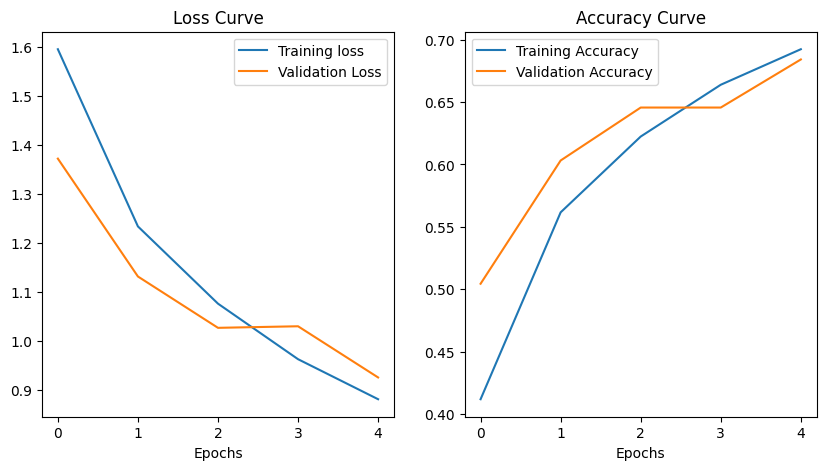

In [16]:
train_loss=history.history['loss']
val_loss=history.history['val_loss']
train_accuracy=history.history['accuracy']
val_accuracy=history.history['val_accuracy']

plt.figure(figsize=(10,5))
plt.subplot(121)
plt.plot(train_loss,label='Training loss')
plt.plot(val_loss,label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(122)
plt.plot(train_accuracy,label='Training Accuracy')
plt.plot(val_accuracy,label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.legend()


In [17]:
history = cnn_model.fit(
    X_train, y_train,
    batch_size=52,
    epochs=10,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/10
770/770 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.7192 - loss: 0.8042 - val_accuracy: 0.6746 - val_loss: 0.9561
Epoch 2/10
770/770 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.7413 - loss: 0.7434 - val_accuracy: 0.6977 - val_loss: 0.8907
Epoch 3/10
770/770 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.7588 - loss: 0.6891 - val_accuracy: 0.6900 - val_loss: 0.9040
Epoch 4/10
770/770 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.7765 - loss: 0.6365 - val_accuracy: 0.7064 - val_loss: 0.8712
Epoch 5/10
770/770 ━━━━━━━━━━━━━━━━━━━━ 45s 37ms/step - accuracy: 0.7928 - loss: 0.5909 - val_accuracy: 0.7013 - val_loss: 0.8878
Epoch 6/10
770/770 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.8102 - loss: 0.5445 - val_accuracy: 0.6995 - val_loss: 0.9384
Epoch 7/10
770/770 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.8214 - loss: 0.5094 - val_accuracy: 0.6988 - val_loss: 0.9362
Epoch 8/10
770/770 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.8357 - loss: 0.4672 - 

In [18]:
#Model performance of the CNN
loss, accuracy = cnn_model.evaluate(X_val, y_val, verbose=0)

print("Performance Analysis of the CNN")
print(f"\nFinal Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy:.4f}")

Performance Analysis of the CNN

Final Validation Loss: 1.0437
Final Validation Accuracy: 0.7017


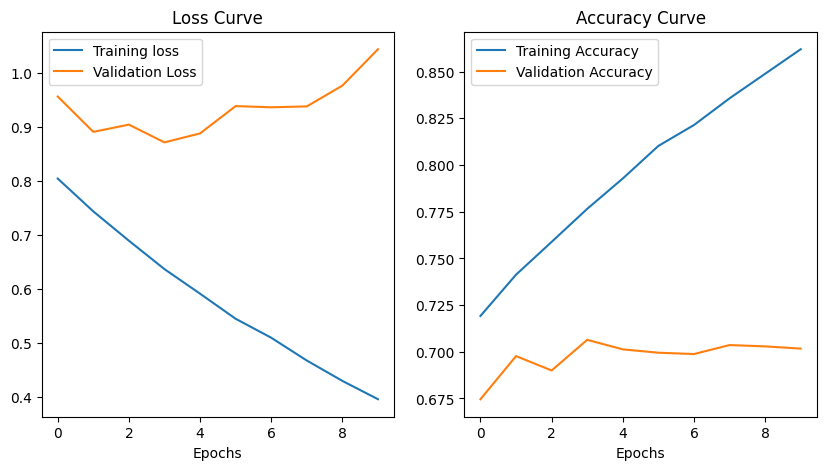

In [19]:
train_loss=history.history['loss']
val_loss=history.history['val_loss']
train_accuracy=history.history['accuracy']
val_accuracy=history.history['val_accuracy']

plt.figure(figsize=(10,5))
plt.subplot(121)
plt.plot(train_loss,label='Training loss')
plt.plot(val_loss,label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(122)
plt.plot(train_accuracy,label='Training Accuracy')
plt.plot(val_accuracy,label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.legend()

In [20]:
from tensorflow.keras.utils import to_categorical # type: ignore``
from tensorflow.keras.models import load_model # type: ignore

cnn_model.save('cnn_model.keras')
trained_cnn_model=load_model('cnn_model.keras')
trained_cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

### 4. Hyperparameter Tuning using Keras tuner

In [21]:
import tensorflow as tf
import keras_tuner
from keras_tuner import RandomSearch
from tensorflow.keras import layers, models, optimizers # type: ignore

def hp_cnn(hp):
    # list all hyperaparameters to tune
    learning_rate = hp.Choice("learning_rate",values=[1e-2, 1e-3, 1e-4, 1e-5])
    activation = hp.Choice('activation', ['relu', 'leaky_relu'])

    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation=activation, input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation=activation),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation=activation),

        layers.Flatten(),
        layers.Dense(64, activation=activation),
        layers.Dense(10, activation='softmax')  # 10 classes
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [22]:
tuner = keras_tuner.RandomSearch(
    hp_cnn,
    objective='val_accuracy',
    max_trials=5,
    directory=r'D:\Advanced_Machine_Learning\Deep_Neural_Networks',
    project_name='tuned_cnn'
)


Reloading Tuner from D:\Advanced_Machine_Learning\Deep_Neural_Networks\tuned_cnn\tuner0.json


In [23]:
tuner.search_space_summary()

Search space summary
Default search space size: 2
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001, 1e-05], 'ordered': True}
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'leaky_relu'], 'ordered': False}


In [ ]:
tuner.search(X_train,y_train,epochs=10,validation_data=(X_val,y_val))

Trial 4 Complete [00h 05m 17s]
val_accuracy: 0.6272000074386597

Best val_accuracy So Far: 0.8931999802589417
Total elapsed time: 174d 22h 06m 59s

Search: Running Trial #5

Value             |Best Value So Far |Hyperparameter
0.01              |0.001             |learning_rate
relu              |leaky_relu        |activation

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 34s 24ms/step - accuracy: 0.1002 - loss: 2.3141 - val_accuracy: 0.1000 - val_loss: 2.3034
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.1011 - loss: 2.3041 - val_accuracy: 0.1000 - val_loss: 2.3037
Epoch 3/10
 347/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.0998 - loss: 2.3043

In [ ]:
best_cnn=tuner.get_best_hyperparameters(num_trials=1)[0]

print(f'Best Learning rate: {best_cnn.get('learning_rate')}')

Best Learning rate: 0.001


Next we just need to retrain our model on the best hyperparameter...

In [ ]:
tuned_cnn = tuner.hypermodel.build(best_cnn)
tuned_cnn.fit(X_train, y_train, 
          validation_data= (X_val,y_val), 
          epochs= 10)

d:\Advanced_Machine_Learning\adml-env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.4260 - loss: 1.5694 - val_accuracy: 0.5482 - val_loss: 1.2787
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.5647 - loss: 1.2198 - val_accuracy: 0.6003 - val_loss: 1.1383
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.6238 - loss: 1.0634 - val_accuracy: 0.6190 - val_loss: 1.0780
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.6614 - loss: 0.9575 - val_accuracy: 0.6499 - val_loss: 0.9922
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.6943 - loss: 0.8766 - val_accuracy: 0.6588 - val_loss: 1.0070
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.7150 - loss: 0.8124 - val_accuracy: 0.6655 - val_loss: 0.9548
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.7369 - loss: 0.7551 - val_accuracy: 0.6845 - val_loss: 0.9197
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.7543 -

Save the hypertuned model and now we are ready to put it to test on unseen data!!!

In [ ]:
tuned_cnn.save('hypertuned_cnn_model.keras')

### 5. Model Evaluation on Tuned model

In [ ]:
# load the optimized model
hypertuned_cnn_model=load_model('hypertuned_cnn_model.keras')

In [ ]:
predictions = hypertuned_cnn_model.predict(X_test[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step


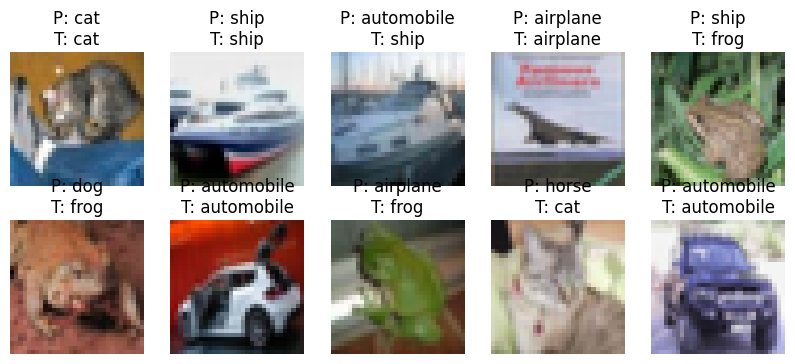

In [ ]:
# Display test images with predicted labels
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i])
    pred_label = class_names[np.argmax(predictions[i])]
    true_label = class_names[y_test[i][0]]
    plt.title(f"P: {pred_label}\nT: {true_label}")
    plt.axis('off')
plt.show()

In [ ]:
# Evaluate tuned model on test set
from sklearn.metrics import classification_report

probs_tuned = hypertuned_cnn_model.predict(X_test, verbose=0)
y_pred_tuned = np.argmax(probs_tuned, axis=1)

print("Tuned model classification report:")
print(classification_report(
    y_test, y_pred_tuned,
    labels=list(range(43)),
    target_names=class_names,
    zero_division=0
))

Tuned model classification report:
              precision    recall  f1-score   support

    airplane       0.40      0.73      0.51      1000
  automobile       0.50      0.84      0.63      1000
        bird       0.75      0.09      0.16      1000
         cat       0.35      0.21      0.27      1000
        deer       0.83      0.04      0.07      1000
         dog       0.48      0.54      0.50      1000
        frog       0.82      0.11      0.20      1000
       horse       0.53      0.62      0.57      1000
        ship       0.43      0.68      0.53      1000
       truck       0.40      0.70      0.51      1000

    accuracy                           0.45     10000
   macro avg       0.13      0.11      0.09     10000
weighted avg       0.55      0.45      0.39     10000



d:\Advanced_Machine_Learning\adml-env\Lib\site-packages\sklearn\metrics\_classification.py:2964: UserWarning: labels size, 43, does not match size of target_names, 10
  warnings.warn(
